In [3]:
import snowflake.connector
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv('../.env')

conn = snowflake.connector.connect(
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
    database=os.getenv('SNOWFLAKE_DATABASE'),
    schema='CLEAN'
)

ibm_maven = pd.read_sql('SELECT * FROM IBM_MAVEN', conn)
kaggle = pd.read_sql('SELECT * FROM KAGGLE_TELECOMS', conn)
ibm_maven['CHURN_BINARY'] = (ibm_maven['CHURN'] == 'Yes').astype(int)

print(f'IBM+Maven: {ibm_maven.shape}')
print(f'Kaggle: {kaggle.shape}')

IBM+Maven: (6589, 35)
Kaggle: (3333, 22)


In [7]:
drop_cols = ['CUSTOMERID', 'CHURN', 'CHURN_CATEGORY', 'CHURN_REASON', 
             'CITY', 'ZIP_CODE', 'CHURN_BINARY', 'TOTAL_REVENUE', 'TOTAL_REFUNDS']
model_df = ibm_maven.copy()
model_df = model_df.drop(columns=drop_cols)

y = ibm_maven['CHURN_BINARY']

cat_cols = model_df.select_dtypes(include=['object', 'bool']).columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = model_df[col].fillna('Unknown')
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    le_dict[col] = le

model_df = model_df.fillna(model_df.median())

X = model_df

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(classification_report(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.3f}")

Random Forest Results:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       944
           1       0.82      0.60      0.69       374

    accuracy                           0.85      1318
   macro avg       0.84      0.77      0.80      1318
weighted avg       0.85      0.85      0.84      1318

ROC AUC: 0.909


In [8]:
print(model_df.columns.tolist())

['GENDER', 'AGE', 'MARRIED', 'DEPENDENTS', 'SENIORCITIZEN', 'TENURE', 'PHONESERVICE', 'MULTIPLELINES', 'INTERNETSERVICE', 'INTERNET_TYPE', 'ONLINESECURITY', 'ONLINEBACKUP', 'DEVICEPROTECTION', 'TECHSUPPORT', 'STREAMINGTV', 'STREAMINGMOVIES', 'STREAMING_MUSIC', 'UNLIMITED_DATA', 'CONTRACT', 'PAPERLESSBILLING', 'PAYMENTMETHOD', 'MONTHLYCHARGES', 'TOTALCHARGES', 'NUMBER_OF_REFERRALS', 'OFFER', 'AVG_MONTHLY_GB_DOWNLOAD']


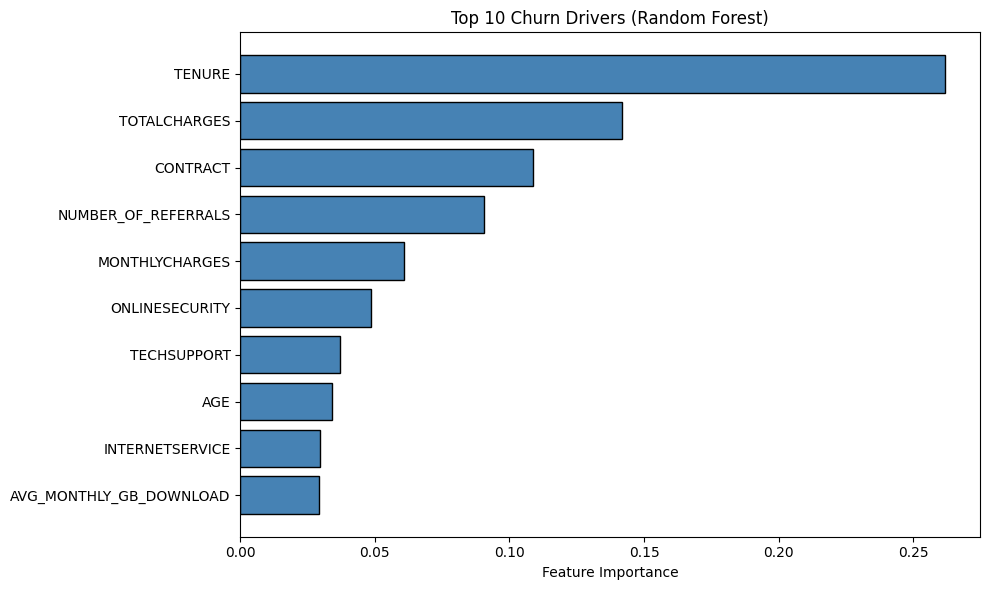

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importances['feature'], importances['importance'], 
        color='steelblue', edgecolor='black')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 10 Churn Drivers (Random Forest)')
plt.tight_layout()
plt.savefig('figures/07_feature_importance.png', dpi=150)
plt.show()

In [11]:
# score all customers
ibm_maven['CHURN_PROBABILITY'] = rf.predict_proba(X)[:, 1]
ibm_maven['RISK_TIER'] = pd.cut(ibm_maven['CHURN_PROBABILITY'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'])

# summary
risk_summary = ibm_maven.groupby('RISK_TIER', observed=True).agg(
    count=('CHURN_PROBABILITY', 'count'),
    avg_prob=('CHURN_PROBABILITY', 'mean'),
    actual_churn=('CHURN_BINARY', 'mean'),
    avg_monthly=('MONTHLYCHARGES', 'mean'),
    avg_tenure=('TENURE', 'mean')
).reset_index()

print(risk_summary.to_string(index=False))

  RISK_TIER  count  avg_prob  actual_churn  avg_monthly  avg_tenure
   Low Risk   4215  0.080841      0.026097    59.956999   43.344958
Medium Risk   1224  0.447015      0.543301    80.793056   28.875000
  High Risk   1149  0.847748      0.952132    73.760487    7.955614
